# Task 3

Due to the simplicity of KNN for Classification, let's focus on using a Pipeline and a GridSearchCV tool, since these skills can be generalized for any model.


## The Sonar Data

### Detecting a Rock or a Mine

Sonar (sound navigation ranging) is a technique that uses sound propagation (usually underwater, as in submarine navigation) to navigate, communicate with or detect objects on or under the surface of the water, such as other vessels.



The data set contains the response metrics for 60 separate sonar frequencies sent out against a known mine field (and known rocks). These frequencies are then labeled with the known object they were beaming the sound at (either a rock or a mine).



Our main goal is to create a machine learning model capable of detecting the difference between a rock or a mine based on the response of the 60 separate sonar frequencies.


Data Source: https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

### Complete the Tasks in bold

**TASK: Run the cells below to load the data.**

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('sonar.all-data.csv')

## Train | Test Split

Our approach here will be one of using Cross Validation on 90% of the dataset, and then judging our results on a final test set of 10% to evaluate our model.

**TASK: Split the data into features and labels, and then split into a training set and test set, with 90% for Cross-Validation training, and 10% for a final test set.**

*Note: The solution uses a random_state=42*

In [5]:
df.head()
df.columns

Index(['Freq_1', 'Freq_2', 'Freq_3', 'Freq_4', 'Freq_5', 'Freq_6', 'Freq_7',
       'Freq_8', 'Freq_9', 'Freq_10', 'Freq_11', 'Freq_12', 'Freq_13',
       'Freq_14', 'Freq_15', 'Freq_16', 'Freq_17', 'Freq_18', 'Freq_19',
       'Freq_20', 'Freq_21', 'Freq_22', 'Freq_23', 'Freq_24', 'Freq_25',
       'Freq_26', 'Freq_27', 'Freq_28', 'Freq_29', 'Freq_30', 'Freq_31',
       'Freq_32', 'Freq_33', 'Freq_34', 'Freq_35', 'Freq_36', 'Freq_37',
       'Freq_38', 'Freq_39', 'Freq_40', 'Freq_41', 'Freq_42', 'Freq_43',
       'Freq_44', 'Freq_45', 'Freq_46', 'Freq_47', 'Freq_48', 'Freq_49',
       'Freq_50', 'Freq_51', 'Freq_52', 'Freq_53', 'Freq_54', 'Freq_55',
       'Freq_56', 'Freq_57', 'Freq_58', 'Freq_59', 'Freq_60', 'Label'],
      dtype='object')

In [6]:
# Features and Labels
X = df.drop('Label', axis=1)
y = df['Label']

# Train | Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (187, 60)
X_test shape: (21, 60)
y_train shape: (187,)
y_test shape: (21,)


**TASK: Create a Pipeline that contains both a StandardScaler and a KNN model**

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: scale features
    ('knn', KNeighborsClassifier())     # Step 2: KNN classifier
])

# Optional: check the pipeline
print(pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


**TASK: Perform a grid-search with the pipeline to test various values of k and report back the best performing parameters.**

In [8]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'knn__n_neighbors': list(range(1, 21)),  # test k from 1 to 20
    'knn__weights': ['uniform', 'distance']  # test uniform vs distance weighting
}

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='accuracy', # optimize for accuracy
    n_jobs=-1           # use all cores for speed
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Report the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Best CV Accuracy: 0.8453769559032717


### Final Model Evaluation

**TASK: Using the grid classifier object from the previous step, get a final performance classification report and confusion matrix.**

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# Use the best estimator from GridSearchCV
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           M       0.92      0.92      0.92        13
           R       0.88      0.88      0.88         8

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21

Confusion Matrix:
 [[12  1]
 [ 1  7]]


Build a KNN pipeline with scaling (StandardScaler) and KNN classifier.
Perform a grid search to tune n_neighbors and weights.
Evaluate the final model on a held-out test set (10% of the data) using classification report and confusion matrix.

Output Analysis
1. Grid Search Results
Best Parameters: {'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
This means the model performs best when using only the closest neighbor and giving all neighbors equal weight.
Best CV Accuracy: 0.845 (~84.5%)
This is the average accuracy across the 5-fold cross-validation on your training set. Pretty solid for a simple KNN on this dataset.
2. Test Set Performance
Overall Accuracy: 0.90 (90%)
Your model did slightly better on the test set than on cross-validation. Could be due to a small, representative test set.
Class-level Metrics:
Mine (M): precision 0.92, recall 0.92 → very few misclassifications.
Rock (R): precision 0.88, recall 0.88 → slightly more mistakes but still strong.

Confusion Matrix:

[[12  1]
 [ 1  7]]


-Only 2 misclassifications out of 21 test samples.

-Shows that KNN is reliably distinguishing between mines and rocks.

**Success:** The pipeline + GridSearchCV approach worked well and is generalizable for any model.

**KNN Insight:** k=1 can work well for small datasets, but may overfit on noisier datasets. Here, it seems the dataset is clean enough for it to perform excellently.



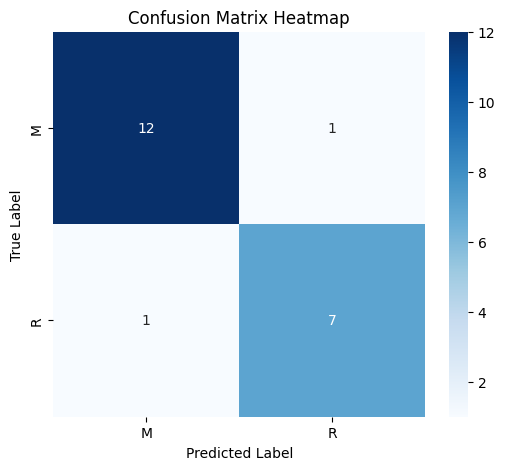

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['M', 'R'])

# Plot as a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['M', 'R'], yticklabels=['M', 'R'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
#a visual of the confusion matrix for better intuition